In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import xarray as xr
import glob
import os
import zipfile
from pyproj import Transformer
import pgeocode
import geopandas as gpd


In [3]:
# This notebook is used to merge historical climate data from met office and ERA5 with known energy consumption values from the sites. 

df_daily = pd.read_parquet('sense_acute_daily.parquet') # from notebook 1

coverage = df_daily.groupby('site_code')['datetime'].agg(['min', 'max']).sort_values('min')
coverage.columns = ['start_date', 'end_date']
print(coverage)

          start_date   end_date
site_code                      
RKB01     2022-12-07 2026-05-08
R0A06     2022-12-07 2026-05-08
R0A07     2022-12-07 2026-05-08
R0A09     2022-12-07 2026-05-08
R0A66     2022-12-07 2026-05-08
RL131     2022-12-07 2026-05-08
RJC46     2022-12-07 2026-05-08
RJC02     2022-12-07 2026-05-08
RH8K6     2022-12-07 2026-05-08
RH868     2022-12-07 2026-05-07
RKB03     2022-12-07 2026-05-08
RH802     2022-12-07 2026-05-08
RFSDA     2022-12-07 2026-05-08
RH801     2022-12-07 2026-05-08
RXN01     2023-02-02 2026-05-08
RXN02     2023-02-02 2026-05-08
RM102     2023-02-02 2026-05-08
RM131     2023-02-02 2026-05-08
RN325     2023-02-02 2026-05-08
RN3G2     2023-02-02 2026-05-08
RQ301     2023-02-02 2026-05-08
RQXM1     2023-02-02 2026-05-08
RLT01     2023-02-02 2026-05-08
RD130     2023-04-05 2026-05-08
RH880     2024-01-27 2026-05-08
RJN63     2024-01-27 2026-05-08
RJN71     2024-01-27 2026-05-08
R0A01     2024-02-08 2025-03-09
RCBP9     2024-03-28 2026-05-08
RCBNH   

In [3]:
print(df_daily['site_use_type'].value_counts())
print(f"Sites remaining: {df_daily['site_name'].nunique()}")


site_use_type
General acute hospital                      25334
Community hospital (with inpatient beds)     6362
Day hospital                                 4597
Specialist hospital (acute only)             3146
Other inpatient                              1953
Mixed service hospital                       1192
Name: count, dtype: int64
Sites remaining: 35


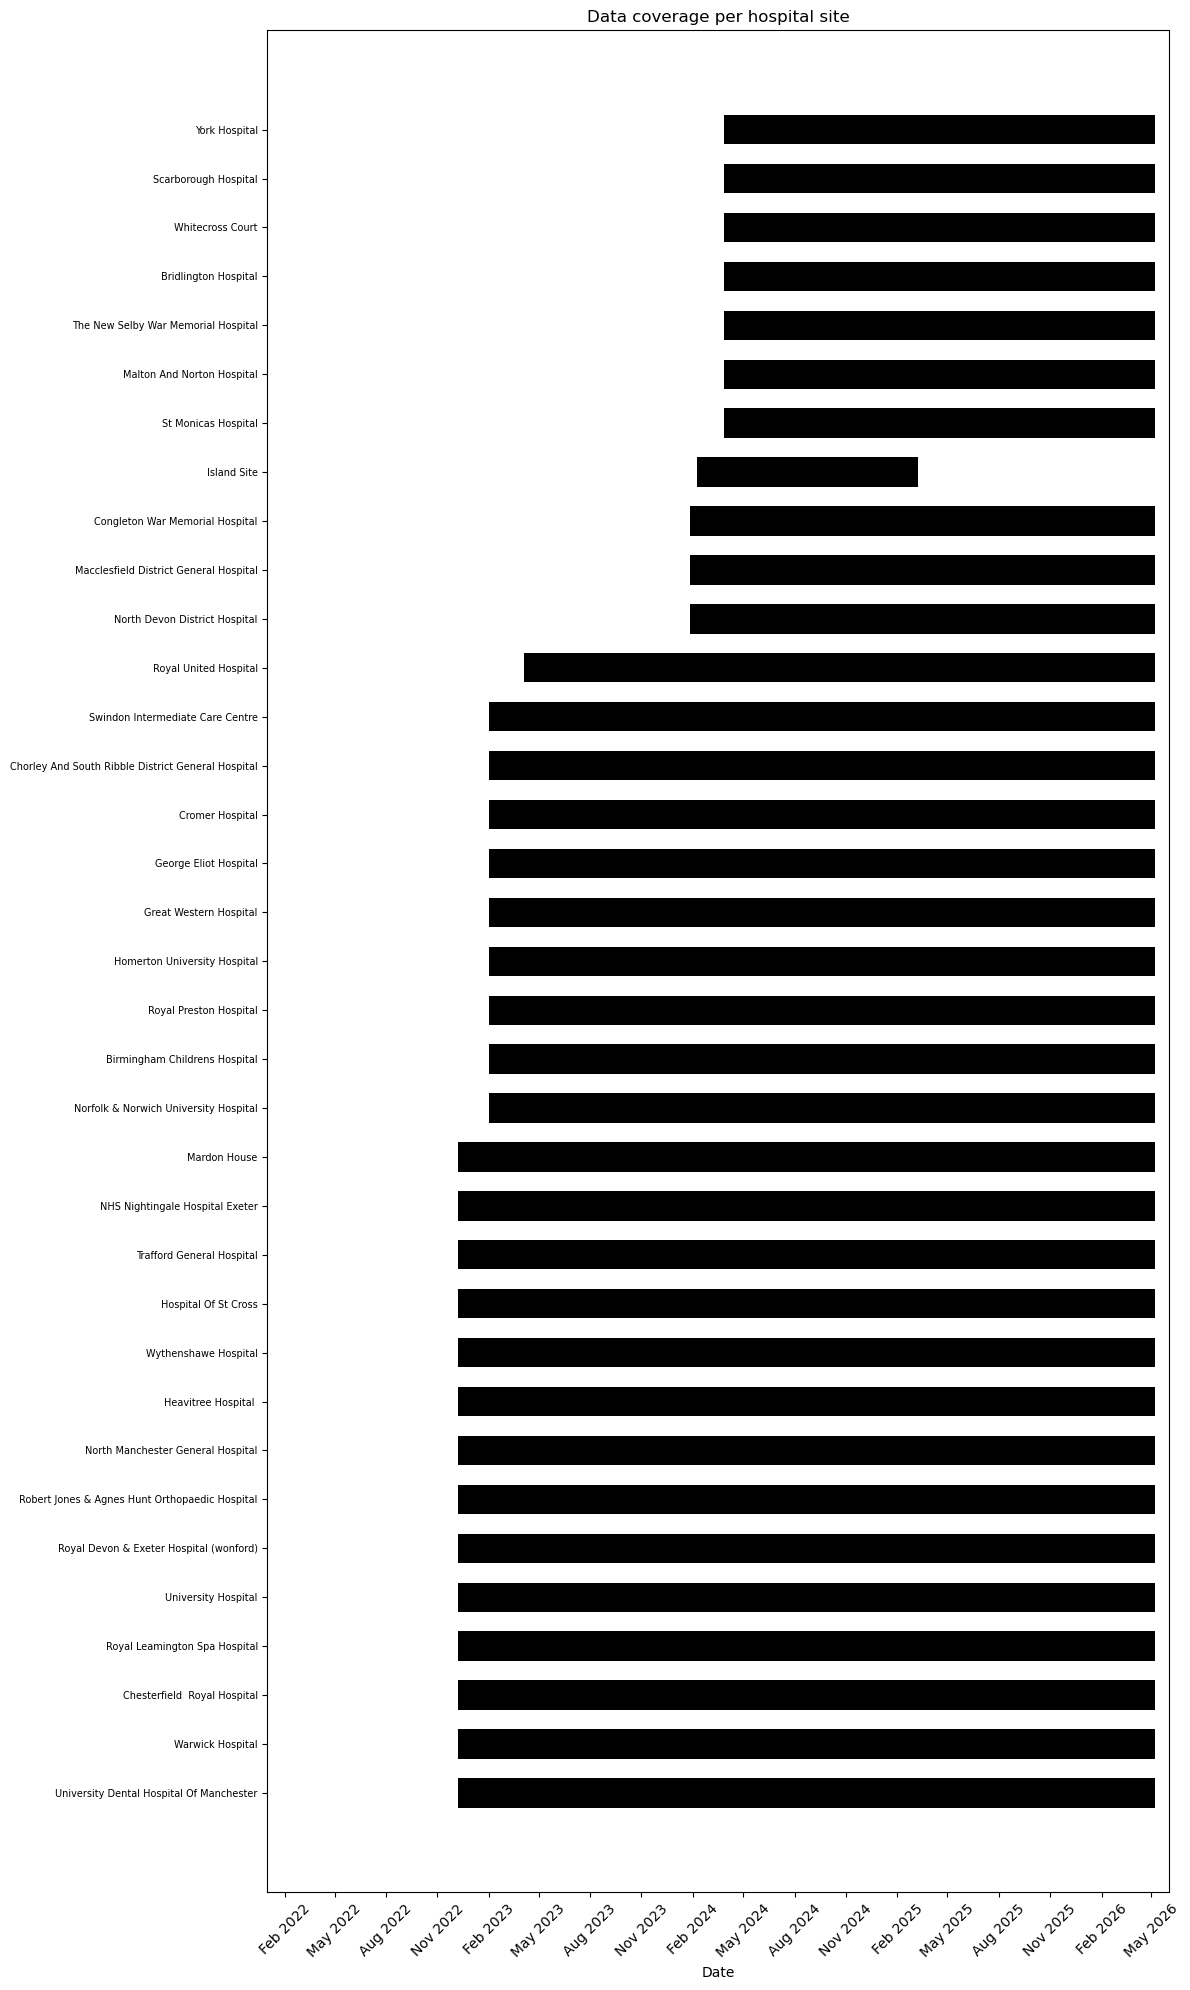

In [5]:
# and visualised:

coverage = df_daily.groupby('site_name')['datetime'].agg(['min', 'max'])
coverage.columns = ['start_date', 'end_date']
coverage = coverage.sort_values('start_date')

fig, ax = plt.subplots(figsize=(12, 20))

for i, (site, row) in enumerate(coverage.iterrows()):
    ax.barh(i, (row['end_date'] - row['start_date']).days, 
            left=row['start_date'], height=0.6, color='black')

ax.set_yticks(range(len(coverage)))
ax.set_yticklabels(coverage.index, fontsize=7)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.set_xlim(pd.Timestamp('2022-01-01'), pd.Timestamp('2026-06-01'))
plt.xticks(rotation=45)
ax.set_xlabel('Date')
ax.set_title('Data coverage per hospital site')
plt.tight_layout()
plt.show()

### all have decent coverage, bar Island Site, but it can still be kept in for now.
# Island site is actually Manchester royal infirmary so quite important.

In [6]:
### additional breakdown of sites with only gas or electricity consumption data (Island Site is Manchester Royal Infirmary, which is a gas-only site):

site_energy = df_daily[df_daily['consumption'] > 0].groupby('site_name')['energy_type'].unique()

for site, types in site_energy.items():
    has_elec = 'elec' in types
    has_gas = 'gas' in types
    if has_gas and not has_elec:
        print(f"{site}: gas only")
    elif has_elec and not has_gas:
        print(f"{site}: elec only")
    elif has_elec and has_gas:
        print(f"{site}: both")

# 34 elec sites
# 9 gas sites
# 8 have both

Birmingham Childrens Hospital: elec only
Bridlington Hospital: elec only
Chesterfield  Royal Hospital: elec only
Chorley And South Ribble District General Hospital: elec only
Congleton War Memorial Hospital: elec only
Cromer Hospital: elec only
George Eliot Hospital: elec only
Great Western Hospital: elec only
Heavitree Hospital : elec only
Homerton University Hospital: both
Hospital Of St Cross: elec only
Island Site: gas only
Macclesfield District General Hospital: elec only
Malton And Norton Hospital: elec only
Mardon House: both
NHS Nightingale Hospital Exeter: both
Norfolk & Norwich University Hospital: elec only
North Devon District Hospital: elec only
North Manchester General Hospital: elec only
Robert Jones & Agnes Hunt Orthopaedic Hospital: both
Royal Devon & Exeter Hospital (wonford): both
Royal Leamington Spa Hospital: elec only
Royal Preston Hospital: both
Royal United Hospital: both
Scarborough Hospital: elec only
St Monicas Hospital: elec only
Swindon Intermediate Care Ce

So, range of climate data to import is from Dec 2022 - May 2026.
- We will import tasmin and tasmax (maximum and minimum daily temperatures) from haduk, and the rest from ERA5.
- Before importing climate data, extract lon and lat values for NHS sites so that data can be merged by location afterwards.

In [7]:
# convert postcodes into geographic coordinates

# get unique sites with postcodes
sites = df_daily.drop_duplicates('site_code')[['site_name', 'site_code', 'postcode']].copy()
print(f"Total sites: {len(sites)}")

# convert postcodes to lat/lon
nomi = pgeocode.Nominatim('gb')
geo = nomi.query_postal_code(sites['postcode'].str.strip().tolist())
sites['latitude'] = geo['latitude'].values
sites['longitude'] = geo['longitude'].values

# convert lat/lon to BNG
transformer = Transformer.from_crs("EPSG:4326", "EPSG:27700", always_xy=True)
sites['easting'], sites['northing'] = transformer.transform(
    sites['longitude'].values, sites['latitude'].values
)

print(sites[['site_name', 'postcode', 'latitude', 'longitude']].head())

Total sites: 35
                                     site_name postcode  latitude  longitude
0                                  Island Site  M13 9WL  53.46980   -2.22950
396   University Dental Hospital Of Manchester  M15 6FH  53.48090   -2.23740
1790                      Wythenshawe Hospital  M23 9LT  53.39470   -2.27900
3039                 Trafford General Hospital  M41 5SL  53.44925   -2.36875
4288         North Manchester General Hospital   M8 5RB  53.49860   -2.23850


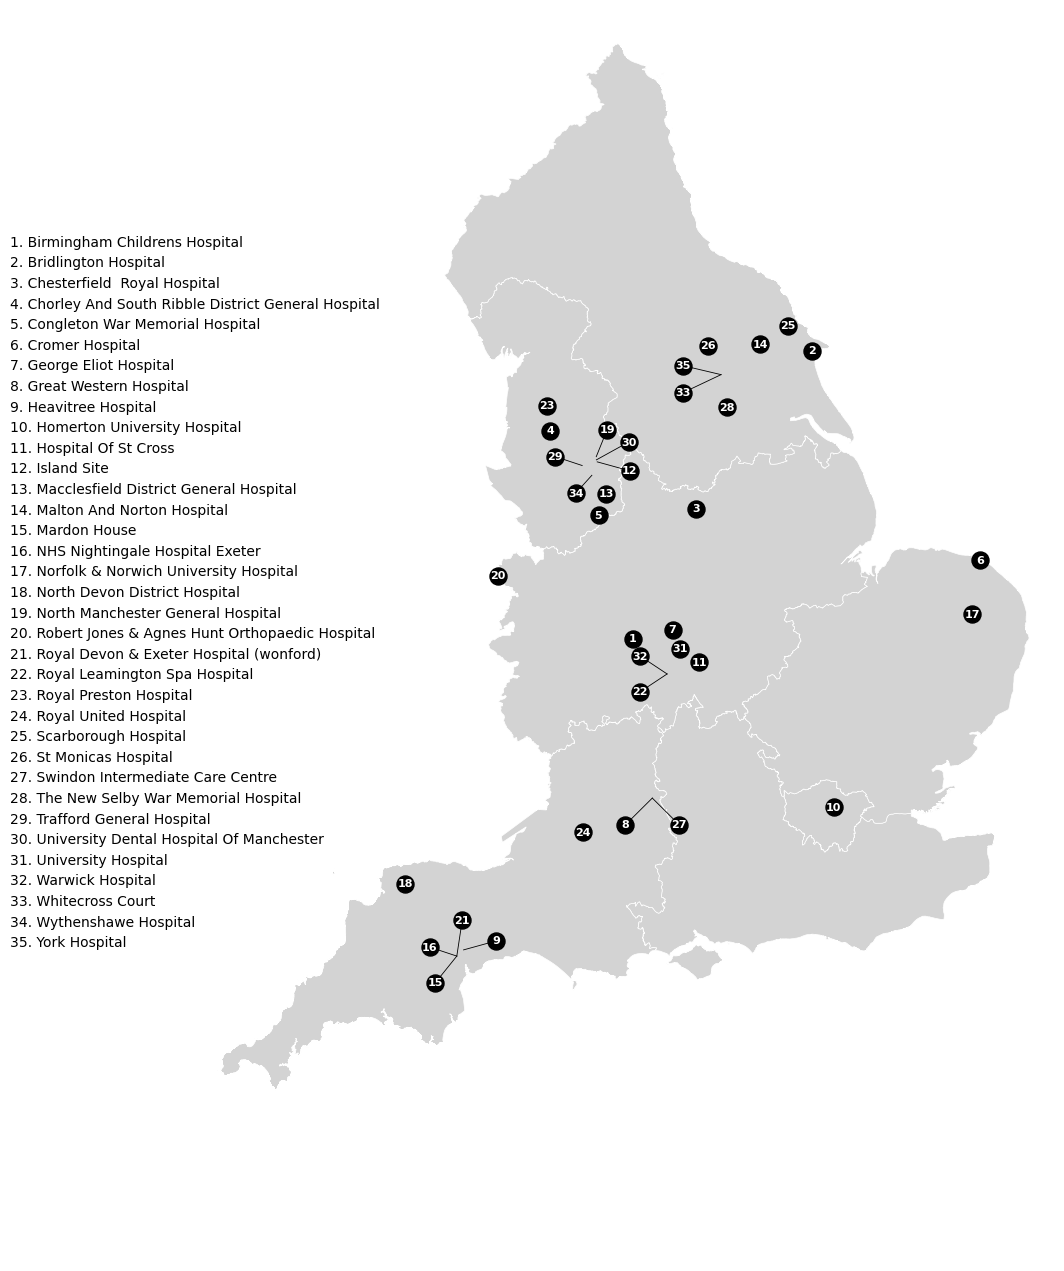

In [ ]:
# plot hospital sites on map of England

# sort alphabetically
sites = sites.sort_values('site_name').reset_index(drop=True)

uk = gpd.read_file('NHS_England_Regions_January_2024_EN_BFE_-6109213648786504635.geojson') # downloaded from https://www.data.gov.uk/dataset/3d226cd2-8996-40ef-a97c-a4e3e5e96f33/nhs-england-regions-january-2024-boundaries-en-bfe, shows NHS commissioning regions
uk = uk.to_crs(epsg=4326)

fig = plt.figure(figsize=(12, 16))
ax_map = fig.add_axes([0.25, 0.02, 0.72, 0.96])
ax_legend = fig.add_axes([0.1, 0.25, 0.25, 0.5])

uk.plot(ax=ax_map, color='lightgrey', edgecolor='white', linewidth=0.5)

overlap_points = {
    8: (-0.25, -0.15),
    9: (0.3, 0.05),
    12: (0.3, -0.05),
    15: (-0.2, -0.15),
    16: (-0.25, 0.05),
    19: (0.1, 0.15),
    21: (0.05, 0.2),
    22: (-0.25, -0.1),
    27: (0.25, -0.15),
    29: (-0.25, 0.05),
    30: (0.3, 0.1),
    32: (-0.25, 0.1),
    33: (-0.35, -0.1),
    34: (-0.15, -0.1),
    35: (-0.35, 0.05),
}

for i, (lon, lat) in enumerate(zip(sites['longitude'].values, sites['latitude'].values)):
    num = i + 1
    dx, dy = overlap_points.get(num, (0, 0))
    label_x, label_y = lon + dx, lat + dy

    if dx or dy:
        ax_map.plot([lon, label_x], [lat, label_y], color='black', linewidth=0.6, zorder=4)

    ax_map.scatter(label_x, label_y, s=150, color='black', zorder=5)
    ax_map.text(label_x, label_y, str(num), fontsize=8, fontweight='bold',
                color='white', ha='center', va='center', zorder=6)

ax_map.set_xlim(-6, 2)
ax_map.set_ylim(49, 56)
ax_map.set_axis_off()
ax_legend.axis('off')
legend_text = '\n'.join([f"{i+1}. {row['site_name']}" for i, (_, row) in enumerate(sites.iterrows())])
ax_legend.text(0, 1, legend_text, fontsize=10, va='top', ha='left',
               transform=ax_legend.transAxes, linespacing=1.6)
plt.show()

In [ ]:
# import tasmin and tasmax climate data
tasmax_files = sorted(glob.glob('climate_data/haduk_historical/tasmax_historical/*.nc'))
tasmin_files = sorted(glob.glob('climate_data/haduk_historical/tasmin_historical/*.nc'))

# extraction function
def extract_haduk(file, sites, var):
    ds = xr.open_dataset(file)
    results = []
    for _, site in sites.iterrows():
        point = ds[var].sel(
            projection_y_coordinate=site['northing'],
            projection_x_coordinate=site['easting'],
            method='nearest'
        )
        df = point.to_dataframe().reset_index()[['time', var]]
        df['site_code'] = site['site_code']
        results.append(df)
    ds.close()
    return pd.concat(results)

# extract tasmax and tasmin data for all sites, convert to degrees C and normalise datetime
tasmax_dfs = [extract_haduk(f, sites, 'tasmax') for f in tasmax_files]
df_tasmax = pd.concat(tasmax_dfs)
df_tasmax = df_tasmax.rename(columns={'time': 'datetime'})
df_tasmax['datetime'] = pd.to_datetime(df_tasmax['datetime']).dt.normalize()

tasmin_dfs = [extract_haduk(f, sites, 'tasmin') for f in tasmin_files]
df_tasmin = pd.concat(tasmin_dfs)
df_tasmin = df_tasmin.rename(columns={'time': 'datetime'})
df_tasmin['datetime'] = pd.to_datetime(df_tasmin['datetime']).dt.normalize()

print(f"tasmax shape: {df_tasmax.shape}, tasmin shape: {df_tasmin.shape}")

tasmax shape: (44730, 3), tasmin shape: (44730, 3)


In [ ]:
# unzip and extract ERA5 variables (already downloaded in notebook 2)
era5_dir = 'climate_data/era5_historical'

for filename in sorted(os.listdir(era5_dir)):
    if not filename.endswith('.nc'):
        continue
    filepath = os.path.join(era5_dir, filename)
    with open(filepath, 'rb') as f:
        header = f.read(4)
    if header == b'PK\x03\x04':
        month_dir = os.path.join(era5_dir, filename.replace('.nc', ''))
        os.makedirs(month_dir, exist_ok=True)
        with zipfile.ZipFile(filepath, 'r') as z:
            z.extractall(month_dir)

subfolders = [f for f in os.listdir(era5_dir) if os.path.isdir(os.path.join(era5_dir, f))]
print(f"Unzipped {len(subfolders)} monthly ERA5 folders")

Unzipped 42 monthly ERA5 folders


In [16]:
# extract ERA5 variables at hospital locations
def get_era5_files_by_var(temp_dir, pattern):
    files = []
    for subfolder in sorted(os.listdir(era5_dir)):
        subfolder_path = os.path.join(era5_dir, subfolder)
        if os.path.isdir(subfolder_path):
            matches = glob.glob(os.path.join(subfolder_path, f'*{pattern}*'))
            files.extend(matches)
    return sorted(files)

era5_dfs = {}
for var_pattern, var_name in [
    ('2m_temperature', 'tas'),
    ('2m_dewpoint', 'td'),
    ('u_component', 'u10'),
    ('v_component', 'v10'),
    ('solar_radiation', 'rsds')
]:
    files = get_era5_files_by_var(era5_dir, var_pattern)
    print(f"{var_name}: {len(files)} files")
    
    records = []
    for f in files:
        ds = xr.open_dataset(f)
        data_vars = [v for v in ds.data_vars if v not in ['number']]
        actual_var = data_vars[0]
        for _, site in sites.iterrows():
            point = ds[actual_var].sel(
                latitude=site['latitude'],
                longitude=site['longitude'],
                method='nearest'
            )
            df = point.to_dataframe().reset_index()[['valid_time', actual_var]]
            df = df.rename(columns={'valid_time': 'datetime', actual_var: var_name})
            df['site_code'] = site['site_code']
            records.append(df)
        ds.close()
    
    era5_dfs[var_name] = pd.concat(records)
    era5_dfs[var_name]['datetime'] = pd.to_datetime(era5_dfs[var_name]['datetime']).dt.normalize()
    print(f"{var_name} shape: {era5_dfs[var_name].shape}")

tas: 42 files
tas shape: (44730, 3)
td: 42 files
td shape: (44730, 3)
u10: 42 files
u10 shape: (44730, 3)
v10: 42 files
v10 shape: (44730, 3)
rsds: 42 files
rsds shape: (44730, 3)


In [ ]:
# merge all ERA5 variables
df_era5 = era5_dfs['tas'].copy()
for var in ['td', 'u10', 'v10', 'rsds']:
    df_era5 = df_era5.merge(era5_dfs[var], on=['datetime', 'site_code'], how='left')

# convert to C, both tas and td are in K (Copernicus)
if df_era5['tas'].mean() > 100:
    df_era5['tas'] = df_era5['tas'] - 273.15
if df_era5['td'].mean() > 100:
    df_era5['td'] = df_era5['td'] - 273.15

# relative humidity calculated from dewpoint and temperature (Magnus formula) (Alduchov p608 equation 2)
# RH is then calculated via dividing actual vapour pressure by saturation vapour pressure, then x100 (references in table below) (Lawrence top of page 226)
df_era5['hurs'] = 100 * (np.exp((17.625 * df_era5['td']) / (243.04 + df_era5['td'])) /
                       np.exp((17.625 * df_era5['tas']) / (243.04 + df_era5['tas'])))

# wind speed: ERA5 is north and weastwards wind speed, CHESS-SCAPE is any direction, so use pythagoras to find overall wind speed from u and v components
df_era5['sfcWind'] = np.sqrt(df_era5['u10']**2 + df_era5['v10']**2)

# solar radiation: ERA5 is hourly statistics averaged to daily mean, so divide by seconds in an hour to convert from J/m2 to W/m2, as used in CHESS-SCAPE
df_era5['rsds'] = df_era5['rsds'] / 3600

# drop intermediate variables
df_era5 = df_era5.drop(columns=['td', 'u10', 'v10'])

print(df_era5.describe())

                            datetime           tas          rsds  \
count                          44730  44730.000000  44730.000000   
mean   2024-08-30 11:59:59.999999744     10.436028    117.612946   
min              2022-12-01 00:00:00     -4.803589      1.871852   
25%              2023-10-16 00:00:00      6.841698     38.199632   
50%              2024-08-30 12:00:00     10.246857     94.736290   
75%              2025-07-16 00:00:00     14.224503    187.517776   
max              2026-05-31 00:00:00     26.092957    351.265167   
std                              NaN      5.069326     88.686935   

               hurs       sfcWind  
count  44730.000000  44730.000000  
mean      80.758118      4.007146  
min       42.476566      0.021082  
25%       74.473835      2.551450  
50%       82.028442      3.792423  
75%       88.104055      5.216846  
max       99.994812     14.425331  
std        9.460833      1.966732  


In [18]:
# merge haduk tasmax/tasmin with ERA5 variables
df_climate = df_tasmax.merge(df_tasmin, on=['datetime', 'site_code'], how='outer')
df_climate = df_climate.merge(df_era5, on=['datetime', 'site_code'], how='outer')

print(f"Climate data shape: {df_climate.shape}")
print(df_climate.isnull().sum())

Climate data shape: (44730, 8)
datetime     0
tasmax       0
site_code    0
tasmin       0
tas          0
rsds         0
hurs         0
sfcWind      0
dtype: int64


In [19]:
# merge with energy data

df_daily['datetime'] = pd.to_datetime(df_daily['datetime']).dt.normalize()
df_merged = df_daily.merge(df_climate, on=['site_code', 'datetime'], how='left')

print(f"df_merged shape: {df_merged.shape}")
print(df_merged.isnull().sum())

df_merged shape: (42584, 26)
site_code                                      0
site_name                                      0
energy_type                                    0
datetime                                       0
consumption                                    0
postcode                                       0
organisation_name                              0
organisation_type                              0
comissioning_region                            0
integrated_care_board                          0
site_gross_internal_area                       0
site_heated_volume                             0
site_construction_year_band                    0
site_use_type                                  0
electricity_reported_kwh_m2                    0
gas_reported_kwh_m2                            0
total_electrical_energy_consumption_kwh        0
kWh_m2                                         0
construction_year_mid                      24985
acute_type                              

In [ ]:
# engineer features

df_merged = df_merged.sort_values(['site_code', 'datetime'])

# degree days
df_merged['HDD'] = (15.5 - df_merged['tas']).clip(lower=0)  
df_merged['CDD'] = (df_merged['tas'] - 22).clip(lower=0)   

# temperature event flags
df_merged['heatwave'] = (df_merged.groupby('site_code')['tasmax']
                         .transform(lambda x: (x >= 26).rolling(3, min_periods=3).sum() >= 3)
                         ).astype(int)
df_merged['extreme_cold'] = (df_merged['tasmin'] < 0).astype(int)

# lagged temperature features (thermal inertia)
df_merged['tas_lag1'] = df_merged.groupby('site_code')['tas'].shift(1)
df_merged['tas_lag3'] = df_merged.groupby('site_code')['tas'].shift(3)
df_merged['tas_7day_mean'] = df_merged.groupby('site_code')['tas'].transform(
    lambda x: x.rolling(7, min_periods=1).mean() # average of last 7 days, including current day
)

# calendar features
df_merged['month'] = df_merged['datetime'].dt.month
df_merged['day_of_week'] = df_merged['datetime'].dt.dayofweek
df_merged['is_weekend'] = (df_merged['day_of_week'] >= 5).astype(int)

print(f"Final df_merged shape: {df_merged.shape}")
print(df_merged[['tasmax', 'tasmin', 'tas', 'hurs', 'sfcWind', 'rsds',
                  'HDD', 'CDD', 'tas_lag1', 'tas_7day_mean']].describe())

Final df_merged shape: (42584, 36)
             tasmax        tasmin           tas          hurs       sfcWind  \
count  42584.000000  42584.000000  42584.000000  42584.000000  42584.000000   
mean      14.844691      7.207048     10.657844     80.785057      3.967628   
std        5.863296      4.895480      4.982078      9.443972      1.939116   
min       -0.727133     -9.363972     -4.467163     42.476566      0.021082   
25%       10.679496      3.721696      7.114311     74.467102      2.530319   
50%       14.547935      7.361885     10.590637     82.003563      3.772583   
75%       19.120381     10.843832     14.381226     88.139366      5.163268   
max       34.365073     20.927344     26.092957     99.994812     14.425331   

               rsds           HDD           CDD      tas_lag1  tas_7day_mean  
count  42584.000000  42584.000000  42584.000000  42549.000000   42584.000000  
mean     118.595177      5.269608      0.005226     10.656759      10.643091  
std       87.533

In [ ]:
feature_table = pd.DataFrame([
    {
        'Feature': 'tas',
        'Description': 'Daily mean air temperature',
        'Units': '°C',
        'Source': 'ERA5 post-processed daily statistics',
        'Resolution': '~28km (0.25°)',
        'Notes': 'Primary temperature predictor, converted from Kelvin'
    },
    {
        'Feature': 'tasmax',
        'Description': 'Daily maximum air temperature',
        'Units': '°C',
        'Source': 'HadUK-Grid v1.3.1',
        'Resolution': '1km',
        'Notes': 'Used to identify peak daily temperature, relevant to cooling demand and heatwave detection'
    },
    {
        'Feature': 'tasmin',
        'Description': 'Daily minimum air temperature',
        'Units': '°C',
        'Source': 'HadUK-Grid v1.3.1',
        'Resolution': '1km',
        'Notes': 'Used for extreme cold detection relevant to overnight temperatures and heating demand'
    },
    {
        'Feature': 'HDD',
        'Description': 'Heating degree days',
        'Units': '°C-days',
        'Source': 'Derived from ERA5 tas',
        'Resolution': '~28km (0.25°)',
        'Notes': 'UK standard threshold temperature of 15.5°C (CIBSE, 2006), below which heating becomes necessary'
    },
    {
        'Feature': 'CDD',
        'Description': 'Cooling degree days',
        'Units': '°C-days',
        'Source': 'Derived from ERA5 tas',
        'Resolution': '~28km (0.25°)',
        'Notes': 'UK standard threshold temperature of 22°C (Spinoni et al., 2015; Azevedo et al., 2015), below which cooling becomes necessary'
    },
    {
        'Feature': 'tas_lag1',
        'Description': 'Previous day mean air temperature',
        'Units': '°C',
        'Source': 'Derived from ERA5 tas',
        'Resolution': '~28km (0.25°)',
        'Notes': 'Captures short-term thermal inertia - 1-day lag'
    },
    {
        'Feature': 'tas_lag3',
        'Description': 'Mean air temperature 3 days prior',
        'Units': '°C',
        'Source': 'Derived from ERA5 tas',
        'Resolution': '~28km (0.25°)',
        'Notes': 'Captures medium-term thermal inertia - 3-day lag'
    },
    {
        'Feature': 'tas_7day_mean',
        'Description': '7-day rolling mean air temperature',
        'Units': '°C',
        'Source': 'Derived from ERA5 tas',
        'Resolution': '~28km (0.25°)',
        'Notes': 'Captures longer-term thermal inertia via sustained thermal conditions over the previous week'
    },
    {
        'Feature': 'heatwave',
        'Description': 'Heatwave day flag',
        'Units': 'Binary (0/1)',
        'Source': 'Derived from HadUK-Grid tasmax',
        'Resolution': '1km',
        'Notes': 'Coded as 1 after 3 or more consecutive days with tasmax >= 26°C (Met Office, 2022)'
    },
    {
        'Feature': 'extreme_cold',
        'Description': 'Below freezing day flag',
        'Units': 'Binary (0/1)',
        'Source': 'Derived from HadUK-Grid tasmin',
        'Resolution': '1km',
        'Notes': 'Coded as 1 when tasmin < 0°C'
    },
    {
        'Feature': 'hurs',
        'Description': 'Near-surface relative humidity',
        'Units': '%',
        'Source': 'ERA5 post-processed daily statistics',
        'Resolution': '~28km (0.25°)',
        'Notes': 'Derived from 2m dewpoint temperature and 2m temperature via Magnus formula. Equations described in Appendices (Lawrence, 2005; Alduchov and Eskridge, 1996)'
    },
    {
        'Feature': 'sfcWind',
        'Description': 'Near-surface wind speed',
        'Units': 'm s⁻¹',
        'Source': 'ERA5 post-processed daily statistics',
        'Resolution': '~28km (0.25°)',
        'Notes': "Derived from 10m eastward and northward wind components via Pythagoras' theorem"
    },
    {
        'Feature': 'rsds',
        'Description': 'Downward shortwave radiation',
        'Units': 'W m⁻²',
        'Source': 'ERA5 post-processed daily statistics',
        'Resolution': '~28km (0.25°)',
        'Notes': 'Measures sunlight intensity - converted from J m⁻²'
    },
    {
        'Feature': 'month',
        'Description': 'Calendar month',
        'Units': '1-12',
        'Source': 'Derived from datetime',
        'Resolution': 'N/A',
        'Notes': 'Captures seasonal patterns in energy consumption'
    },
    {
        'Feature': 'day_of_week',
        'Description': 'Day of week',
        'Units': '0-6 (0=Monday)',
        'Source': 'Derived from datetime',
        'Resolution': 'N/A',
        'Notes': 'Captures weekly operational patterns'
    },
    {
        'Feature': 'is_weekend',
        'Description': 'Weekend flag',
        'Units': 'Binary (0/1)',
        'Source': 'Derived from datetime',
        'Resolution': 'N/A',
        'Notes': 'Saturday and Sunday coded as 1 - captures differences in hospital activity at weekends'
    }
])

feature_table.to_excel('feature_table.xlsx', index=False)
print(f"Saved feature_table.xlsx ({len(feature_table)} features)")
display(feature_table)

Saved feature_table.xlsx (16 features)


,Feature,Description,Units,Source,Resolution,Notes
0,tas,Daily mean air temperature,°C,ERA5 post-processed daily statistics,~28km (0.25°),"Primary temperature predictor, converted from ..."
1,tasmax,Daily maximum air temperature,°C,HadUK-Grid v1.3.1,1km,"Used to identify peak daily temperature, relev..."
2,tasmin,Daily minimum air temperature,°C,HadUK-Grid v1.3.1,1km,Used for extreme cold detection relevant to ov...
3,HDD,Heating degree days,°C-days,Derived from ERA5 tas,~28km (0.25°),UK standard threshold temperature of 15.5°C (C...
4,CDD,Cooling degree days,°C-days,Derived from ERA5 tas,~28km (0.25°),UK standard threshold temperature of 22°C (Spi...
5,tas_lag1,Previous day mean air temperature,°C,Derived from ERA5 tas,~28km (0.25°),Captures short-term thermal inertia - 1-day lag
6,tas_lag3,Mean air temperature 3 days prior,°C,Derived from ERA5 tas,~28km (0.25°),Captures medium-term thermal inertia - 3-day lag
7,tas_7day_mean,7-day rolling mean air temperature,°C,Derived from ERA5 tas,~28km (0.25°),Captures longer-term thermal inertia via susta...
8,heatwave,Heatwave day flag,Binary (0/1),Derived from HadUK-Grid tasmax,1km,Coded as 1 after 3 or more consecutive days wi...
9,extreme_cold,Below freezing day flag,Binary (0/1),Derived from HadUK-Grid tasmin,1km,Coded as 1 when tasmin < 0°C


In [25]:

df_merged.to_parquet('sense_acute_climate.parquet', index=False)